In [ ]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamelog

seasons = [
    '2015-16', '2016-17', '2017-18', '2018-19', '2019-20',
    '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26'
]

all_seasons_data = []

for season in seasons:
    print(f"Fetching {season}...")
    
    try:
        game_log = leaguegamelog.LeagueGameLog(
            season=season,
            player_or_team_abbreviation='P',
            season_type_all_star='Regular Season'  # ✅ excludes playoffs
        )
        
        df_season = game_log.get_data_frames()[0]
        df_season['SEASON'] = season
        
        all_seasons_data.append(df_season)
        
        time.sleep(2)

    except Exception as e:
        print(f"Error fetching {season}: {e}")

df_all_stats = pd.concat(all_seasons_data, ignore_index=True)

Fetching 2015-16...
Fetching 2016-17...
Fetching 2017-18...
Fetching 2018-19...
Fetching 2019-20...
Fetching 2020-21...
Fetching 2021-22...
Fetching 2022-23...
Fetching 2023-24...
Fetching 2024-25...
Fetching 2025-26...


In [53]:
# Assuming you have df_grouped from the previous step with a 'BIRTH_DATE' or 'AGE' column
def predict_stats(df_last, df_prev):
    # Merge the two seasons
    df_pred = pd.merge(df_last, df_prev, on='PLAYER_ID', suffixes=('_25', '_24'))
    
    # Weighted Average (70/30 rule)
    df_pred['PRED_PTS'] = (df_pred['PTS_PG_25'] * 0.7) + (df_pred['PTS_PG_24'] * 0.3)
    
    # Simple Age Multiplier (Growth for young, Decay for old)
    # If age < 24: factor = 1.10 | If age > 33: factor = 0.90
    df_pred['AGE_FACTOR'] = df_pred['AGE'].apply(lambda x: 1.1 if x < 24 else (0.9 if x > 33 else 1.0))
    df_pred['FINAL_PRED_PTS'] = df_pred['PRED_PTS'] * df_pred['AGE_FACTOR']
    
    return df_pred

In [54]:
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# --- 1. CONFIGURATION & PREP ---
CURRENT_SEASON = '2025-26'
PREV_SEASON = '2024-25'
MAX_GAMES = 82

def clean_and_prep(df):
    df = df.copy()
    # Handle 'MIN' format (e.g., '35:12' -> 35.2)
    if df['MIN'].dtype == 'O':
        df['MIN'] = df['MIN'].apply(lambda x: int(x.split(':')[0]) + int(x.split(':')[1])/60 
                                  if (isinstance(x, str) and ':' in x) else (float(x) if pd.notna(x) else 0))
    
    # Feature Engineering: Double-Doubles & Stocks
    dd_cats = ['PTS', 'REB', 'AST', 'STL', 'BLK']
    df['DD'] = ((df[dd_cats] >= 10).sum(axis=1) >= 2).astype(int)
    df['STOCKS'] = df['STL'] + df['BLK']
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    return df

def aggregate_stats(df, label=""):
    agg_map = {
        'GAME_ID': 'count', 'MIN': 'sum', 'FGM': 'sum', 'FGA': 'sum',
        'FTM': 'sum', 'FTA': 'sum', 'FG3M': 'sum', 'REB': 'sum',
        'AST': 'sum', 'STL': 'sum', 'BLK': 'sum', 'PTS': 'sum', 'DD': 'sum'
    }
    grouped = df.groupby(['PLAYER_ID', 'PLAYER_NAME']).agg(agg_map).reset_index()
    grouped.rename(columns={'GAME_ID': 'GP'}, inplace=True)
    
    # Filter: Minimum baseline for statistical relevance
    grouped = grouped[(grouped['GP'] >= 15) & ((grouped['MIN']/grouped['GP']) >= 12)]
    
    # Per-Game & Efficiency Calculations
    for s in ['FG3M', 'REB', 'AST', 'STL', 'BLK', 'PTS', 'DD']:
        grouped[f'{s}_PG'] = grouped[s] / grouped['GP']
        
    grouped['FG_PCT'] = grouped['FGM'] / grouped['FGA']
    grouped['FT_PCT'] = grouped['FTM'] / grouped['FTA']
    # INTEGRATED: Points Per Minute
    grouped['PTS_MIN'] = grouped['PTS'] / grouped['MIN']
    
    if label:
        grouped = grouped.add_suffix(f'_{label}')
        grouped.rename(columns={f'PLAYER_ID_{label}': 'PLAYER_ID', f'PLAYER_NAME_{label}': 'PLAYER_NAME'}, inplace=True)
    return grouped

# --- 2. DATA PROCESSING ---
df_clean = clean_and_prep(df_all_stats)

# Historical Reliability (GP over last 3 years)
gp_history = df_clean.groupby(['PLAYER_ID', 'PLAYER_NAME', 'SEASON'])['GAME_ID'].count().reset_index()
reliability = gp_history.groupby(['PLAYER_ID', 'PLAYER_NAME'])['GAME_ID'].mean().reset_index()
reliability.rename(columns={'GAME_ID': 'AVG_GP'}, inplace=True)
reliability['RELIABILITY_SCORE'] = (reliability['AVG_GP'] / MAX_GAMES).clip(0.2, 1.0)

# Extract Seasons & Late Breakouts
df_26 = aggregate_stats(df_clean[df_clean['SEASON'] == CURRENT_SEASON], label="26")
df_25 = aggregate_stats(df_clean[df_clean['SEASON'] == PREV_SEASON], label="25")
last_15 = df_clean[df_clean['SEASON'] == CURRENT_SEASON].sort_values('GAME_DATE').groupby('PLAYER_ID').tail(15)
df_late = aggregate_stats(last_15, label="LATE")

# Merge Everything
df_master = pd.merge(df_26, df_25, on=['PLAYER_ID', 'PLAYER_NAME'], how='left')
df_master = pd.merge(df_master, reliability[['PLAYER_ID', 'RELIABILITY_SCORE']], on='PLAYER_ID', how='left')
df_master = pd.merge(df_master, df_late[['PLAYER_ID', 'PTS_PG_LATE', 'PTS_MIN_LATE']], on='PLAYER_ID', how='left')

# --- 3. PREDICTIONS & Z-SCORES ---
predict_cats = ['PTS_PG', 'REB_PG', 'AST_PG', 'STL_PG', 'BLK_PG', 'FG3M_PG', 'DD_PG', 'FG_PCT', 'FT_PCT', 'PTS_MIN']

for cat in predict_cats:
    # 70/30 Season Weighting
    df_master[f'PRED_{cat}'] = (df_master[f'{cat}_26'] * 0.7) + (df_master[f'{cat}_25'].fillna(df_master[f'{cat}_26']) * 0.3)
    
    # Sleeper Boost (Late season surge)
    if cat in ['PTS_PG', 'PTS_MIN']:
        mask = df_master[f'{cat}_LATE'] > (df_master[f'{cat}_26'] * 1.15)
        df_master.loc[mask, f'PRED_{cat}'] *= 1.08 # 8% Breakout multiplier

# Calculate Z-Scores
for cat in predict_cats:
    col = f'PRED_{cat}'
    df_master[f'Z_{cat}'] = (df_master[col] - df_master[col].mean()) / df_master[col].std()

# --- 4. VOLUME & STRATEGY WEIGHTING ---
df_master['EXP_GP'] = (df_master['RELIABILITY_SCORE'] * MAX_GAMES).round(0)
df_master['RISK_FLAG'] = np.where(df_master['RELIABILITY_SCORE'] < 0.75, 'HIGH RISK', 'STABLE')

# Seasonal Value (Per-Game Z * GP Availability)
for cat in predict_cats:
    df_master[f'V_TOTAL_{cat}'] = df_master[f'Z_{cat}'] * (df_master['EXP_GP'] / MAX_GAMES)

# Strategy Rankings
val_cols = [f'V_TOTAL_{cat}' for cat in predict_cats]
df_master['DRAFT_VALUE_TOTAL'] = df_master[val_cols].sum(axis=1)

# Punt FT% Big Man Build (Emphasis on REB, BLK, FG%, DD, and PTS_MIN)
big_man_cats = ['V_TOTAL_REB_PG', 'V_TOTAL_BLK_PG', 'V_TOTAL_FG_PCT', 'V_TOTAL_DD_PG', 'V_TOTAL_PTS_MIN']
df_master['PUNT_FT_RANK'] = df_master[big_man_cats].sum(axis=1)

# --- 5. VISUALIZATION ---

df_master['Offense_Axis'] = df_master['Z_PTS_PG'] + df_master['Z_AST_PG'] + df_master['Z_PTS_MIN'] + df_master['Z_FG3M_PG'] + df_master['Z_FT_PCT'] + df_master['Z_STL_PG']
df_master['Defense_Axis'] = df_master['Z_REB_PG'] + df_master['Z_FG_PCT'] + df_master['Z_BLK_PG'] + df_master['Z_DD_PG']

viz_df = df_master.sort_values('DRAFT_VALUE_TOTAL', ascending=False).head(200)

chart = alt.Chart(viz_df).mark_circle(size=120).encode(
    x=alt.X('Defense_Axis:Q', title='Defensive Impact (REB+FG%+BLK+DD)'),
    y=alt.Y('Offense_Axis:Q', title='Offensive Impact (PTS+AST+STL+PTS_MIN+FG3M+FT%+)'),
    color=alt.Color('RISK_FLAG:N', scale=alt.Scale(domain=['STABLE', 'HIGH RISK'], range=['#2ecc71', '#e74c3c'])),
    size=alt.Size('EXP_GP:Q', scale=alt.Scale(range=[40, 400]), title="Proj. Games"),
    tooltip=['PLAYER_NAME', 'EXP_GP', 'RISK_FLAG', 
             alt.Tooltip('PRED_PTS_MIN:Q', format='.2f', title='Pts/Min'),
             alt.Tooltip('DRAFT_VALUE_TOTAL:Q', format='.2f', title='Draft Value')]
).properties(width=800, height=500, title="2026-27 Fantasy Draft Matrix").interactive()

chart.display()

alt.Chart(...)

In [55]:
# --- 6. AUCTION VALUE CALCULATION ---

# Parameters
NUM_TEAMS = 10
BUDGET_PER_TEAM = 200
TOTAL_BUDGET = NUM_TEAMS * BUDGET_PER_TEAM
ROSTER_SIZE = 13 # 10 starters + 3 bench
TOTAL_PLAYERS_DRAFTED = NUM_TEAMS * ROSTER_SIZE # 130 players

# 1. Sort by Draft Value and identify the "Draftable" pool
df_auction = df_master.sort_values('DRAFT_VALUE_TOTAL', ascending=False).reset_index(drop=True)

# 2. Identify the Replacement Level Value
# The 130th player is the last one drafted. Their value is our "Floor".
replacement_value = df_auction.iloc[TOTAL_PLAYERS_DRAFTED]['DRAFT_VALUE_TOTAL']

# 3. Calculate "Value Above Replacement" (VAR)
df_auction['VAR'] = (df_auction['DRAFT_VALUE_TOTAL'] - replacement_value).clip(lower=0)

# 4. Allocate Budget
# Reserve $1 for every drafted player as a minimum bid
MIN_BID = 1
total_min_bids = TOTAL_PLAYERS_DRAFTED * MIN_BID
remaining_budget = TOTAL_BUDGET - total_min_bids

# 5. Scale VAR to the remaining budget
total_var = df_auction['VAR'].head(TOTAL_PLAYERS_DRAFTED).sum()
df_auction['ESTIMATED_DOLLAR_VALUE'] = (df_auction['VAR'] / total_var) * remaining_budget
df_auction['ESTIMATED_DOLLAR_VALUE'] = (df_auction['ESTIMATED_DOLLAR_VALUE'] + MIN_BID).round(2)

# Set players outside the top 130 to $0 or $1
df_auction.loc[TOTAL_PLAYERS_DRAFTED:, 'ESTIMATED_DOLLAR_VALUE'] = 0

# --- 7. FINAL BIG BOARD OUTPUT ---
cols_to_show = [
    'PLAYER_NAME', 'ESTIMATED_DOLLAR_VALUE', 'EXP_GP', 
    'RISK_FLAG', 'DRAFT_VALUE_TOTAL', 'PUNT_FT_RANK'
]

print(f"--- 2026-27 AUCTION DRAFT BOARD (${BUDGET_PER_TEAM} Budget) ---")
print(df_auction[cols_to_show].head(20).to_string(index=False))

# --- 8. UPDATED VISUALIZATION WITH DOLLAR VALUES ---
viz_df_auction = df_auction.head(150).copy()

chart_auction = alt.Chart(viz_df_auction).mark_circle(size=120).encode(
    x=alt.X('Defense_Axis:Q', title='Defensive Impact'),
    y=alt.Y('Offense_Axis:Q', title='Offensive Impact'),
    color=alt.Color('ESTIMATED_DOLLAR_VALUE:Q', scale=alt.Scale(scheme='goldgreen'), title="Auction $"),
    size=alt.Size('ESTIMATED_DOLLAR_VALUE:Q', scale=alt.Scale(range=[50, 1000]), title="Value"),
    tooltip=['PLAYER_NAME', 'ESTIMATED_DOLLAR_VALUE', 'EXP_GP', 'RISK_FLAG']
).properties(width=800, height=800, title="Auction Value Matrix: Who to Overspend On?").interactive()

chart_auction.display()

--- 2026-27 AUCTION DRAFT BOARD ($200 Budget) ---
            PLAYER_NAME  ESTIMATED_DOLLAR_VALUE  EXP_GP RISK_FLAG  DRAFT_VALUE_TOTAL  PUNT_FT_RANK
           Nikola Jokić                   77.13    73.0    STABLE          21.854957     12.439201
            Luka Dončić                   53.88    64.0    STABLE          15.503230      6.111686
      Victor Wembanyama                   53.54    58.0 HIGH RISK          15.410241     12.000538
  Giannis Antetokounmpo                   42.93    67.0    STABLE          12.510657     10.604053
Shai Gilgeous-Alexander                   41.43    65.0    STABLE          12.103224      4.568234
     Karl-Anthony Towns                   37.98    65.0    STABLE          11.159506      8.567432
           Tyrese Maxey                   36.98    63.0    STABLE          10.886006      1.856002
           James Harden                   36.76    69.0    STABLE          10.826164      2.747739
        Anthony Edwards                   35.53    73.0    

alt.Chart(...)

In [56]:
df_auction[df_auction.PLAYER_NAME == 'Cooper Flag']

,PLAYER_ID,PLAYER_NAME,GP_26,MIN_26,FGM_26,FGA_26,FTM_26,FTA_26,FG3M_26,REB_26,AST_26,STL_26,BLK_26,PTS_26,DD_26,FG3M_PG_26,REB_PG_26,AST_PG_26,STL_PG_26,BLK_PG_26,PTS_PG_26,DD_PG_26,FG_PCT_26,FT_PCT_26,PTS_MIN_26,GP_25,MIN_25,FGM_25,FGA_25,FTM_25,FTA_25,FG3M_25,REB_25,AST_25,STL_25,BLK_25,PTS_25,DD_25,FG3M_PG_25,REB_PG_25,AST_PG_25,STL_PG_25,BLK_PG_25,PTS_PG_25,DD_PG_25,FG_PCT_25,FT_PCT_25,PTS_MIN_25,RELIABILITY_SCORE,PTS_PG_LATE,PTS_MIN_LATE,PRED_PTS_PG,PRED_REB_PG,PRED_AST_PG,PRED_STL_PG,PRED_BLK_PG,PRED_FG3M_PG,PRED_DD_PG,PRED_FG_PCT,PRED_FT_PCT,PRED_PTS_MIN,Z_PTS_PG,Z_REB_PG,Z_AST_PG,Z_STL_PG,Z_BLK_PG,Z_FG3M_PG,Z_DD_PG,Z_FG_PCT,Z_FT_PCT,Z_PTS_MIN,EXP_GP,RISK_FLAG,V_TOTAL_PTS_PG,V_TOTAL_REB_PG,V_TOTAL_AST_PG,V_TOTAL_STL_PG,V_TOTAL_BLK_PG,V_TOTAL_FG3M_PG,V_TOTAL_DD_PG,V_TOTAL_FG_PCT,V_TOTAL_FT_PCT,V_TOTAL_PTS_MIN,DRAFT_VALUE_TOTAL,PUNT_FT_RANK,Offense_Axis,Defense_Axis,VAR,ESTIMATED_DOLLAR_VALUE


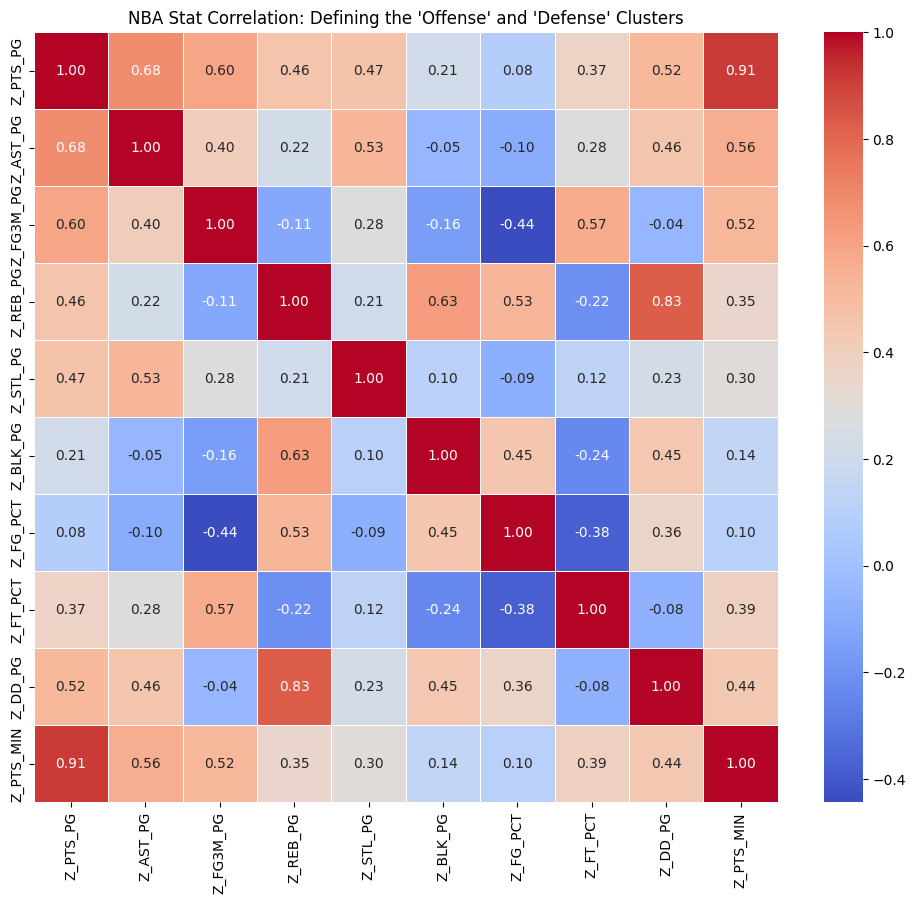

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. These are the correct names based on the latest integrated script
corr_cols = [
    'Z_PTS_PG', 'Z_AST_PG', 'Z_FG3M_PG', 
    'Z_REB_PG', 'Z_STL_PG', 'Z_BLK_PG', 
    'Z_FG_PCT', 'Z_FT_PCT', 'Z_DD_PG',
    'Z_PTS_MIN'
]

# 2. Safety check: Filter for only columns that actually exist in df_master
existing_cols = [c for c in corr_cols if c in df_master.columns]

# 3. Print what's missing if any (for debugging)
missing = set(corr_cols) - set(existing_cols)
if missing:
    print(f"Note: These columns were not found and skipped: {missing}")

# 4. Calculate Correlation and Plot
if existing_cols:
    corr_matrix = df_master[existing_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("NBA Stat Correlation: Defining the 'Offense' and 'Defense' Clusters")
    plt.show()
else:
    print("Error: No matching Z-score columns found. Check your df_master.columns!")

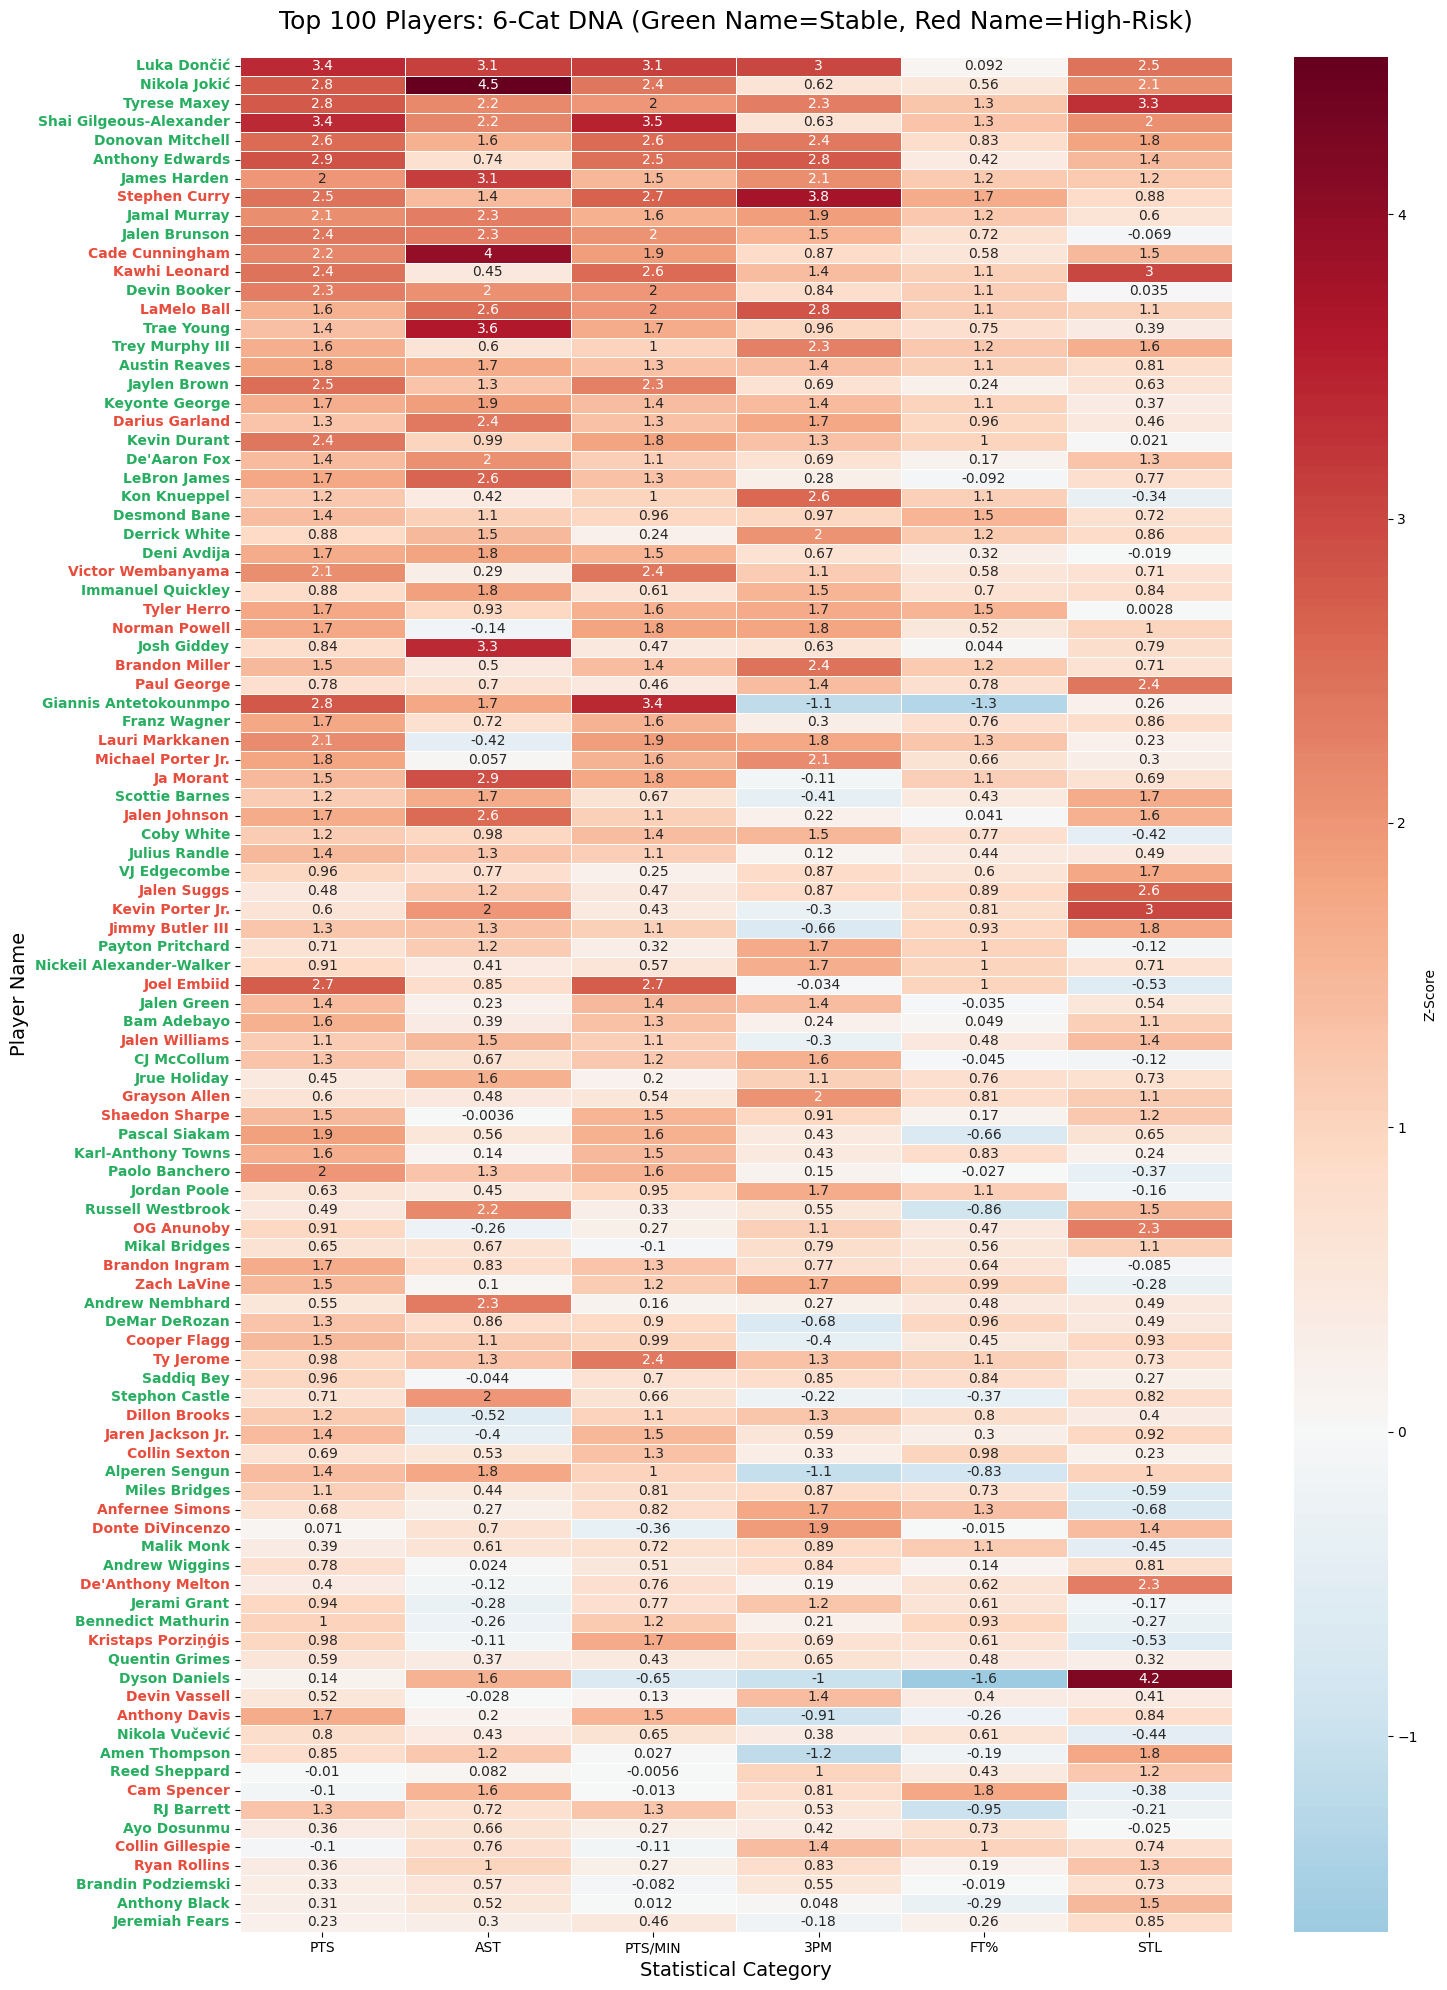

In [58]:
# --- 1. DEFINE YOUR WINNING CATEGORIES ---
target_cats = ['Z_PTS_PG', 'Z_AST_PG', 'Z_PTS_MIN', 'Z_FG3M_PG', 'Z_FT_PCT', 'Z_STL_PG']

# --- 2. CALCULATE CUSTOM VALUE & APPLY STABILITY ---
# Sum the Z-scores for your 6 specific categories
df_master['CUSTOM_BASE_VALUE'] = df_master[target_cats].sum(axis=1)

# Multiply by games played to punish injury-prone players
df_master['CUSTOM_TOTAL_VALUE'] = df_master['CUSTOM_BASE_VALUE'] * (df_master['EXP_GP'] / MAX_GAMES)

# --- 3. LEAGUE BUDGET SETTINGS ---
NUM_TEAMS = 10
BUDGET_PER_TEAM = 200
TOTAL_BUDGET = NUM_TEAMS * BUDGET_PER_TEAM
ROSTER_SIZE = 13
TOTAL_PLAYERS_DRAFTED = NUM_TEAMS * ROSTER_SIZE # 130 players

# Sort players by your custom strategy value
df_auction = df_master.sort_values('CUSTOM_TOTAL_VALUE', ascending=False).reset_index(drop=True)

# --- 4. AUCTION MATH (Value Above Replacement) ---
# Find the value of the worst player drafted (Rank 130)
replacement_value = df_auction.iloc[TOTAL_PLAYERS_DRAFTED - 1]['CUSTOM_TOTAL_VALUE']

# Calculate Value Above Replacement (VAR) - anyone below 130 gets 0 VAR
df_auction['VAR'] = (df_auction['CUSTOM_TOTAL_VALUE'] - replacement_value).clip(lower=0)

# Reserve $1 for every player drafted
MIN_BID = 1
total_min_bids = TOTAL_PLAYERS_DRAFTED * MIN_BID
remaining_budget = TOTAL_BUDGET - total_min_bids

# Distribute the remaining budget proportionally based on VAR
total_var = df_auction['VAR'].sum()
df_auction['EST_DOLLAR_VALUE'] = (df_auction['VAR'] / total_var) * remaining_budget
df_auction['EST_DOLLAR_VALUE'] = (df_auction['EST_DOLLAR_VALUE'] + MIN_BID).round(0) # Round to whole dollars

# Players outside the top 130 are only worth $1 if you absolutely need them, otherwise $0
df_auction.loc[TOTAL_PLAYERS_DRAFTED:, 'EST_DOLLAR_VALUE'] = 0

# --- 5. UPDATED CLEAN OUTPUT (The DNA Table) ---

# We'll show the Z-scores for each category to see where the value comes from
# Let's create a "display" list that includes names and your 6 categories
z_display_cols = [
    'PLAYER_NAME', 'EST_DOLLAR_VALUE', 'EXP_GP', 'RISK_FLAG', 'CUSTOM_TOTAL_VALUE',
    'Z_PTS_PG', 'Z_AST_PG', 'Z_PTS_MIN', 'Z_FG3M_PG', 'Z_FT_PCT', 'Z_STL_PG'
]



# 1. Prepare data (Top 50 for better readability on screen)
top_n = 100
heatmap_data = df_auction.head(top_n).set_index('PLAYER_NAME')[target_cats]
heatmap_data.columns = ['PTS', 'AST', 'PTS/MIN', '3PM', 'FT%', 'STL']

# 2. Create the Plot
plt.figure(figsize=(15, 20))
ax = sns.heatmap(heatmap_data, annot=True, cmap='RdBu_r', center=0, linewidths=.5, cbar_kws={'label': 'Z-Score'})

# 3. COLOR THE LABELS (The Magic Part)
# Create a dictionary for quick lookup: {PlayerName: Color}
risk_colors = {
    row['PLAYER_NAME']: '#27ae60' if row['RISK_FLAG'] == 'STABLE' else '#e74c3c' 
    for _, row in df_auction.head(top_n).iterrows()
}

# Apply colors to the Y-axis (Player Names)
for tick in ax.get_yticklabels():
    player_name = tick.get_text()
    if player_name in risk_colors:
        tick.set_color(risk_colors[player_name])
        tick.set_weight('bold') # Make names pop

# 4. Final Touches
plt.title(f"Top {top_n} Players: 6-Cat DNA (Green Name=Stable, Red Name=High-Risk)", fontsize=18, pad=20)
plt.ylabel("Player Name", fontsize=14)
plt.xlabel("Statistical Category", fontsize=14)

plt.tight_layout()
plt.show()

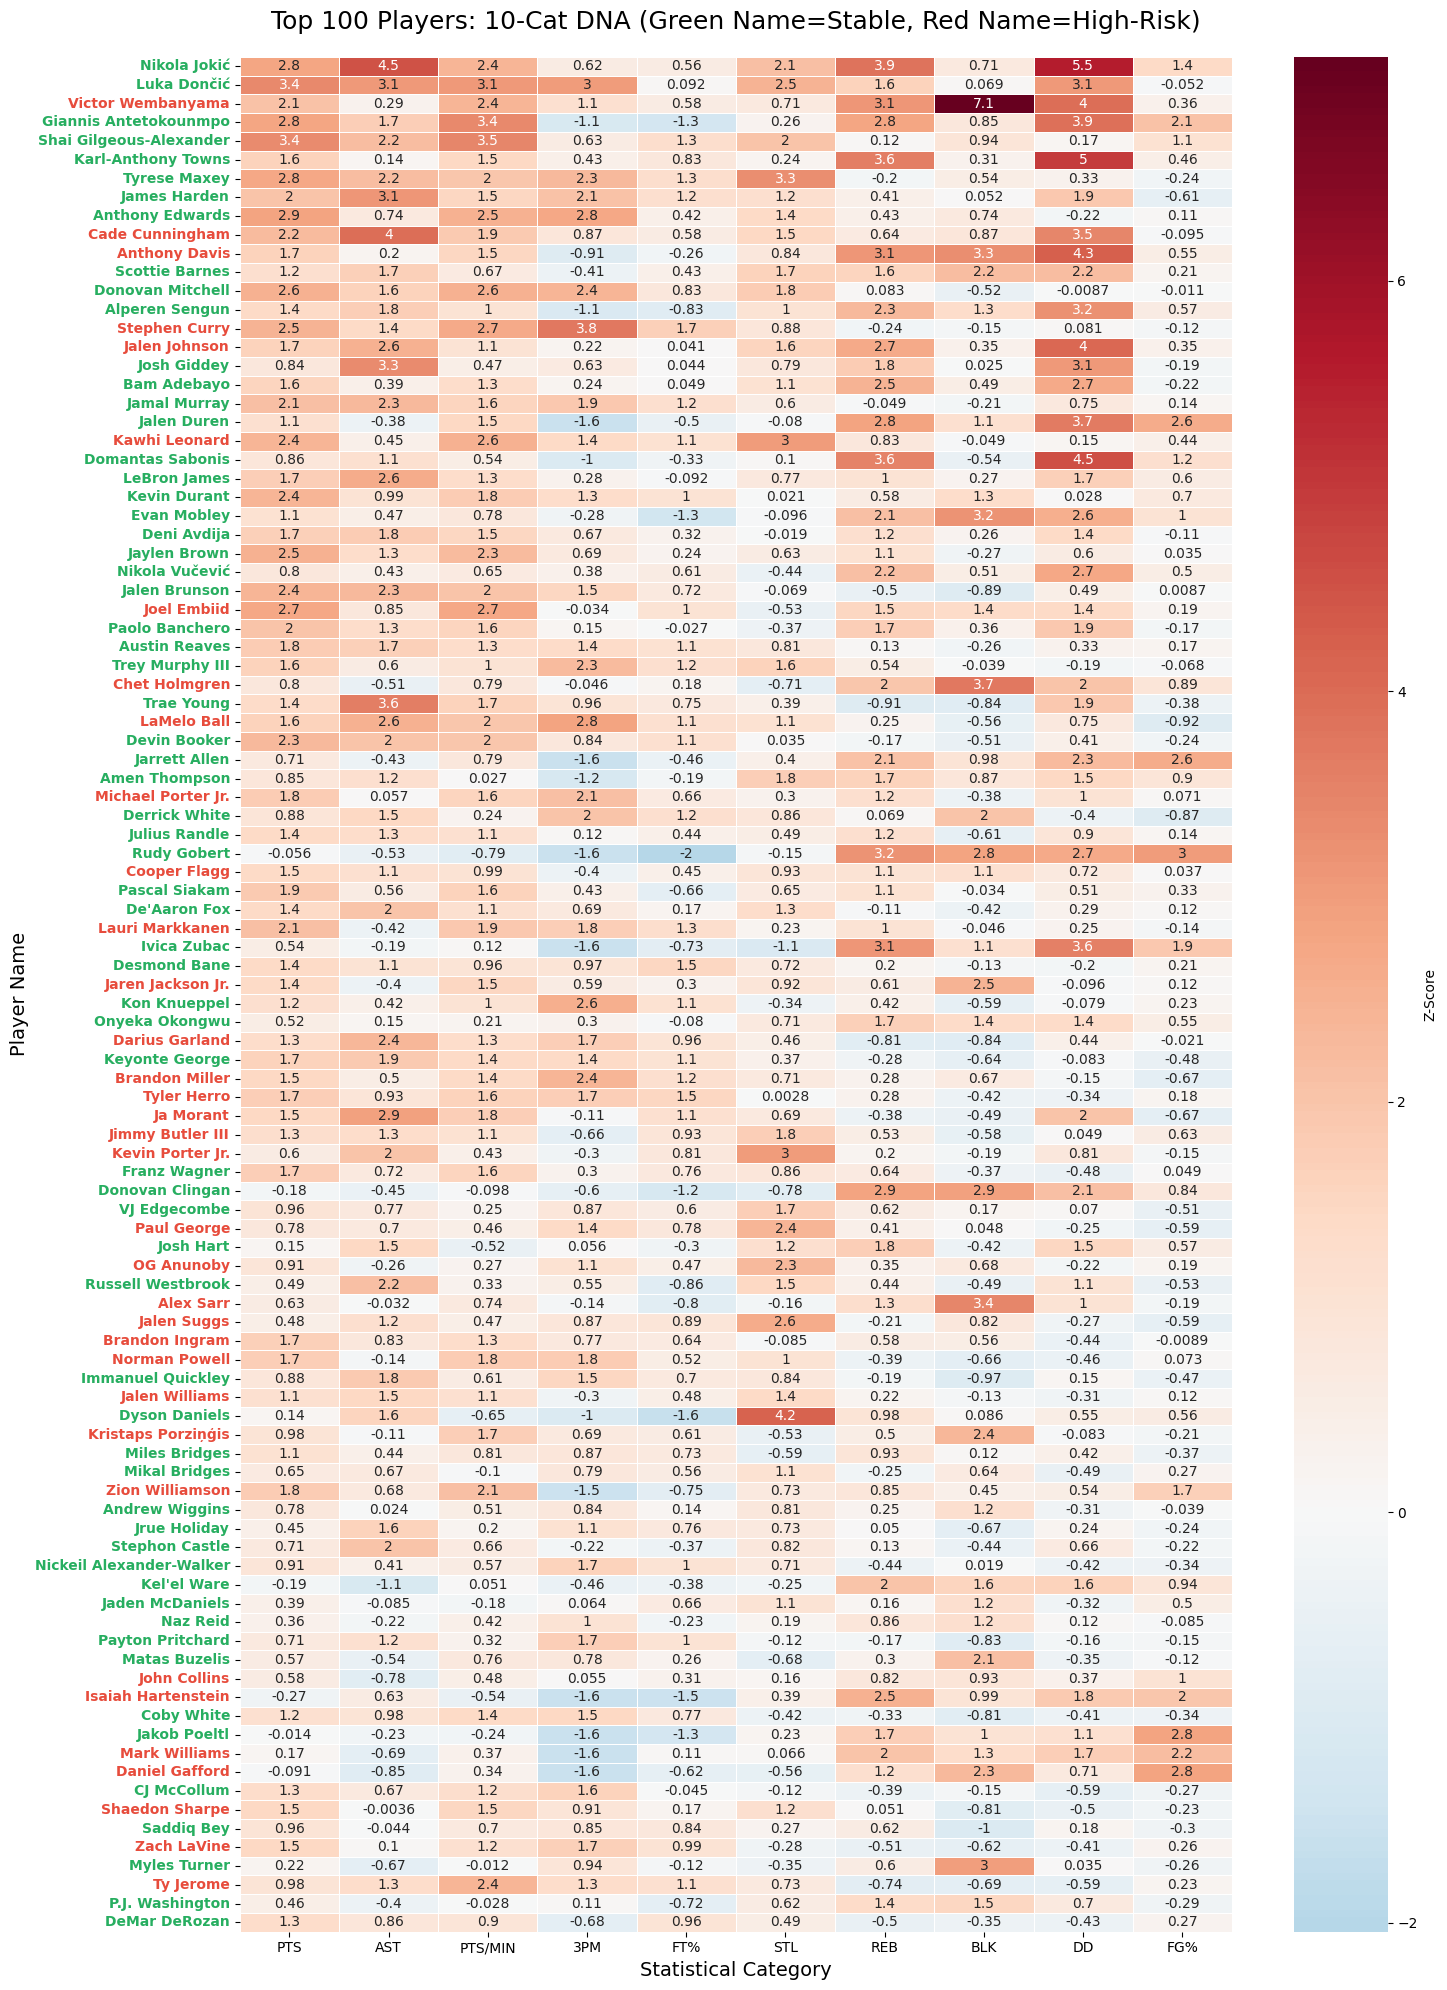

In [59]:
# --- 1. DEFINE YOUR WINNING CATEGORIES ---
target_cats = ['Z_PTS_PG', 'Z_AST_PG', 'Z_PTS_MIN', 'Z_FG3M_PG', 'Z_FT_PCT', 'Z_STL_PG', 'Z_REB_PG', 'Z_BLK_PG', 'Z_DD_PG', 'Z_FG_PCT']

# --- 2. CALCULATE CUSTOM VALUE & APPLY STABILITY ---
# Sum the Z-scores for your 6 specific categories
df_master['CUSTOM_BASE_VALUE'] = df_master[target_cats].sum(axis=1)

# Multiply by games played to punish injury-prone players
df_master['CUSTOM_TOTAL_VALUE'] = df_master['CUSTOM_BASE_VALUE'] * (df_master['EXP_GP'] / MAX_GAMES)

# --- 3. LEAGUE BUDGET SETTINGS ---
NUM_TEAMS = 10
BUDGET_PER_TEAM = 200
TOTAL_BUDGET = NUM_TEAMS * BUDGET_PER_TEAM
ROSTER_SIZE = 13
TOTAL_PLAYERS_DRAFTED = NUM_TEAMS * ROSTER_SIZE # 130 players

# Sort players by your custom strategy value
df_auction = df_master.sort_values('CUSTOM_TOTAL_VALUE', ascending=False).reset_index(drop=True)

# --- 4. AUCTION MATH (Value Above Replacement) ---
# Find the value of the worst player drafted (Rank 130)
replacement_value = df_auction.iloc[TOTAL_PLAYERS_DRAFTED - 1]['CUSTOM_TOTAL_VALUE']

# Calculate Value Above Replacement (VAR) - anyone below 130 gets 0 VAR
df_auction['VAR'] = (df_auction['CUSTOM_TOTAL_VALUE'] - replacement_value).clip(lower=0)

# Reserve $1 for every player drafted
MIN_BID = 1
total_min_bids = TOTAL_PLAYERS_DRAFTED * MIN_BID
remaining_budget = TOTAL_BUDGET - total_min_bids

# Distribute the remaining budget proportionally based on VAR
total_var = df_auction['VAR'].sum()
df_auction['EST_DOLLAR_VALUE'] = (df_auction['VAR'] / total_var) * remaining_budget
df_auction['EST_DOLLAR_VALUE'] = (df_auction['EST_DOLLAR_VALUE'] + MIN_BID).round(0) # Round to whole dollars

# Players outside the top 130 are only worth $1 if you absolutely need them, otherwise $0
df_auction.loc[TOTAL_PLAYERS_DRAFTED:, 'EST_DOLLAR_VALUE'] = 0

# --- 5. UPDATED CLEAN OUTPUT (The DNA Table) ---

# We'll show the Z-scores for each category to see where the value comes from
# Let's create a "display" list that includes names and your 6 categories
z_display_cols = [
    'PLAYER_NAME', 'EST_DOLLAR_VALUE', 'EXP_GP', 'RISK_FLAG', 'CUSTOM_TOTAL_VALUE',
    'Z_PTS_PG', 'Z_AST_PG', 'Z_PTS_MIN', 'Z_FG3M_PG', 'Z_FT_PCT', 'Z_STL_PG', 'Z_REB_PG', 'Z_BLK_PG', 'Z_DD_PG', 'Z_FG_PCT'
]



# 1. Prepare data (Top 50 for better readability on screen)
top_n = 100
heatmap_data = df_auction.head(top_n).set_index('PLAYER_NAME')[target_cats]
heatmap_data.columns = ['PTS', 'AST', 'PTS/MIN', '3PM', 'FT%', 'STL', 'REB', 'BLK', 'DD', 'FG%']

# 2. Create the Plot
plt.figure(figsize=(15, 20))
ax = sns.heatmap(heatmap_data, annot=True, cmap='RdBu_r', center=0, linewidths=.5, cbar_kws={'label': 'Z-Score'})

# 3. COLOR THE LABELS (The Magic Part)
# Create a dictionary for quick lookup: {PlayerName: Color}
risk_colors = {
    row['PLAYER_NAME']: '#27ae60' if row['RISK_FLAG'] == 'STABLE' else '#e74c3c' 
    for _, row in df_auction.head(top_n).iterrows()
}

# Apply colors to the Y-axis (Player Names)
for tick in ax.get_yticklabels():
    player_name = tick.get_text()
    if player_name in risk_colors:
        tick.set_color(risk_colors[player_name])
        tick.set_weight('bold') # Make names pop

# 4. Final Touches
plt.title(f"Top {top_n} Players: 10-Cat DNA (Green Name=Stable, Red Name=High-Risk)", fontsize=18, pad=20)
plt.ylabel("Player Name", fontsize=14)
plt.xlabel("Statistical Category", fontsize=14)

plt.tight_layout()
plt.show()